# [MAIN QUEST 01] Space Titanic 생존자 예측 프로젝트

## 1. 프로젝트 개요 (Overview)
- **프로젝트 목적**: 우주선 타이타닉호(Spaceship Titanic)의 승객 데이터를 분석하여, 시공간 이상 현상으로 인해 다른 차원으로 전송(Transported)된 승객을 예측하는 머신러닝 분류 모델을 개발합니다.
- **데이터셋**: 캐글(Kaggle) 제공 데이터 (train.csv, test.csv)
- **평가 지표**: 정확도 (Accuracy) / **목표 성능**: 80.5% (0.805) 이상

## 2. 목차 (Table of Contents)
1. 프로젝트 개요
2. 목차
3. 라이브러리 및 데이터 살펴보기
4. 탐색적 데이터 분석 (EDA) 및 시각화
5. 데이터 전처리 및 피처 엔지니어링
6. 모델 학습, 튜닝 및 평가
7. 최종 예측 및 제출 파일 생성 (Prediction & Submission)
8. 프로젝트 회고 (Retrospective)
9. 참고 문헌 (References)

---

## **3. 라이브러리 및 데이터 살펴보기**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Windows)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

train_df = pd.read_csv('./data/train.csv')
test_df = pd.read_csv('./data/test.csv')

- 먼저 데이터를 확인해봅니다

In [2]:
train_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [3]:
test_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [4]:
print(train_df.shape)
print(test_df.shape)

(8693, 14)
(4277, 13)


- train data, test data의 결측치를 확인해봅니다

In [5]:
train_df.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [6]:
test_df.isnull().sum()

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

- 이러한 결측치를 missingno를 이용하면 시각화해볼 수 있다
(만약 ModuleNotFoundError 에러 발생 시 `!pip install missingno` 를 실행하여 설치해주세요)

<Axes: >

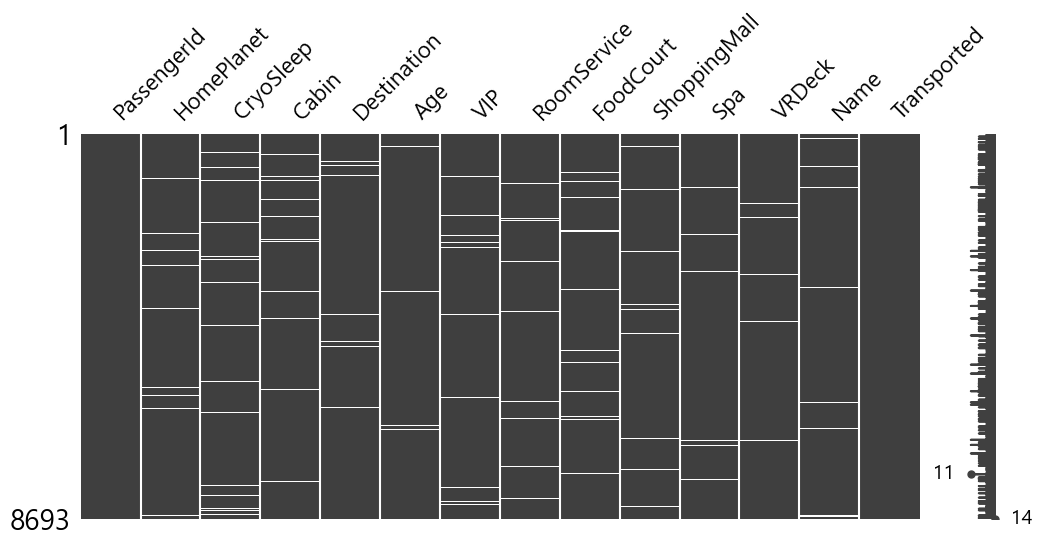

In [7]:
msno.matrix(train_df, figsize=(12, 5))

## **4. 탐색적 데이터 분석 (EDA) 및 시각화**

### **4-1. target 변수 ( Transported )**

In [8]:
train_df["Transported"].value_counts()

Transported
True     4378
False    4315
Name: count, dtype: int64

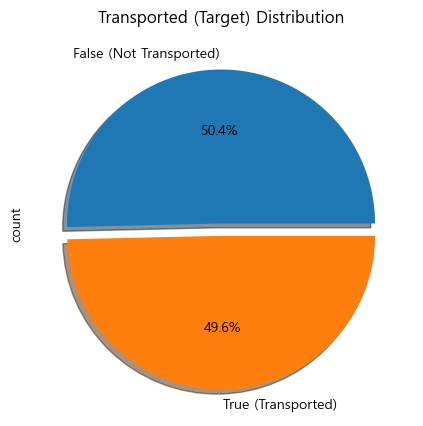

In [9]:
plt.figure(figsize=(8, 5))
labels = ['False (Not Transported)', 'True (Transported)']
train_df['Transported'].value_counts().plot.pie(explode=[0, 0.08], shadow=True, autopct='%1.1f%%', labels=labels)
plt.title('Transported (Target) Distribution')
plt.show()

- 전송된 승객(True)과 전송되지 않은 승객(False)의 비율이 비슷합니다.

### **4-2. 동면 여부 ( CryoSleep )**

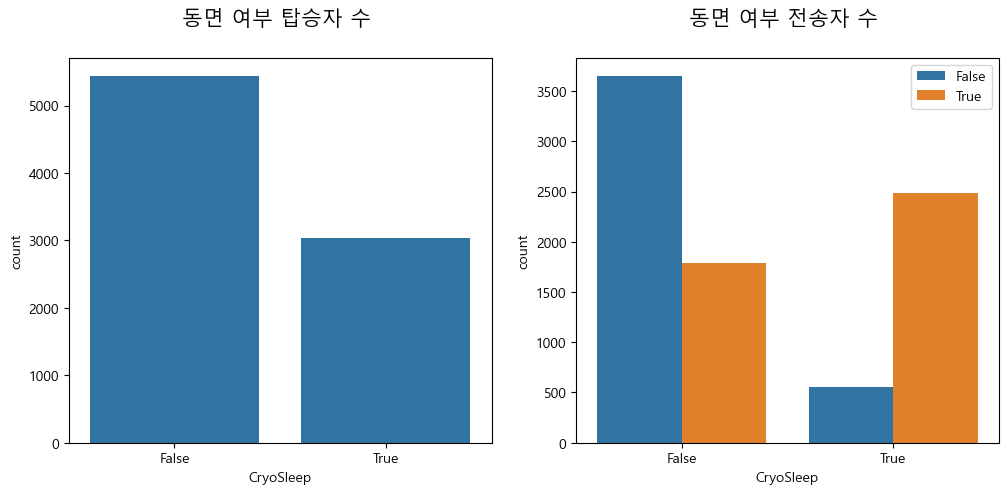

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("동면 여부 탑승자 수 \n", size=15)
sns.countplot(x="CryoSleep", data=train_df, ax=axes[0])

axes[1].set_title("동면 여부 전송자 수 \n", size=15)
sns.countplot(x="CryoSleep", hue="Transported", data=train_df, ax=axes[1])
axes[1].legend(labels=['False', 'True'])
plt.show()

,Transported
CryoSleep,
False,0.328921
True,0.817583


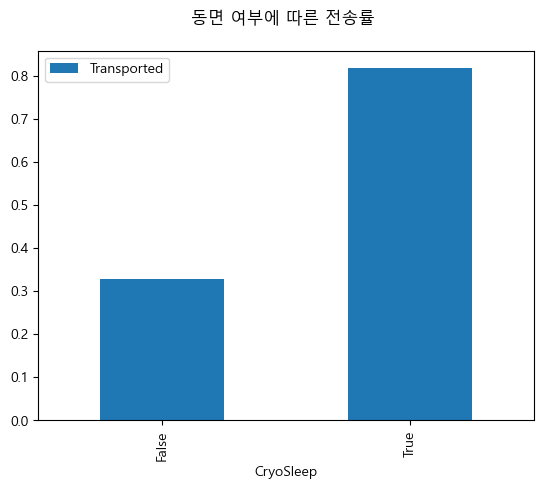

In [11]:
# 동면 여부에 따른 전송률
sur = train_df[['CryoSleep', 'Transported']].groupby('CryoSleep').mean().plot.bar()
sur.set_title("동면 여부에 따른 전송률 \n")
train_df[['CryoSleep', 'Transported']].groupby('CryoSleep').mean()

- 동면(CryoSleep) 상태인 승객이 전송(Transported)될 확률이 매우 높음을 시각화를 통해 확인했습니다.

### **4-3. VIP 여부 ( VIP )**

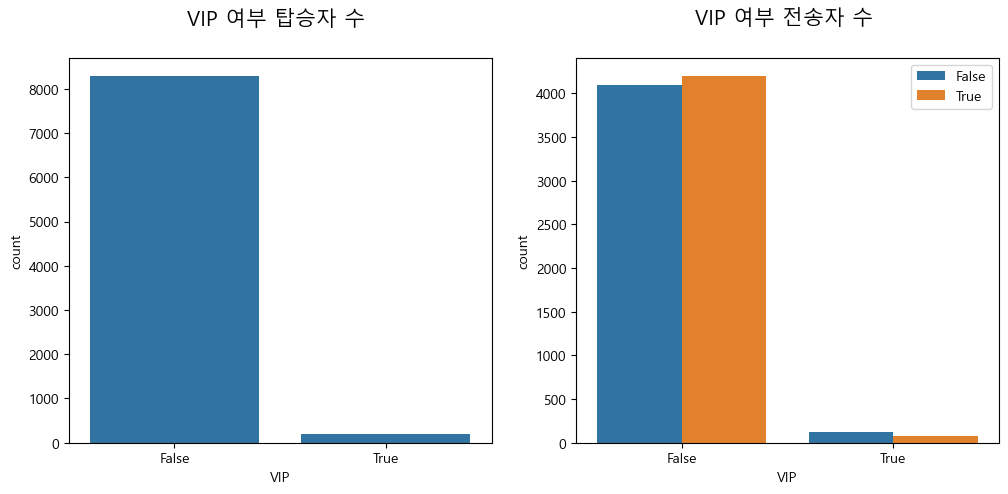

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("VIP 여부 탑승자 수 \n", size=15)
sns.countplot(x="VIP", data=train_df, ax=axes[0])

axes[1].set_title("VIP 여부 전송자 수 \n", size=15)
sns.countplot(x="VIP", hue="Transported", data=train_df, ax=axes[1])
axes[1].legend(labels=['False', 'True'])
plt.show()

In [13]:
train_df[['VIP', 'Transported']].groupby('VIP').mean()

,Transported
VIP,
False,0.506332
True,0.381910


- VIP인 경우 탑승자 수가 매우 적고, VIP 여부가 전송 확률에 유의미한 차이를 보이지는 않는 것으로 보입니다.

### **4-4. 나이 ( Age )**

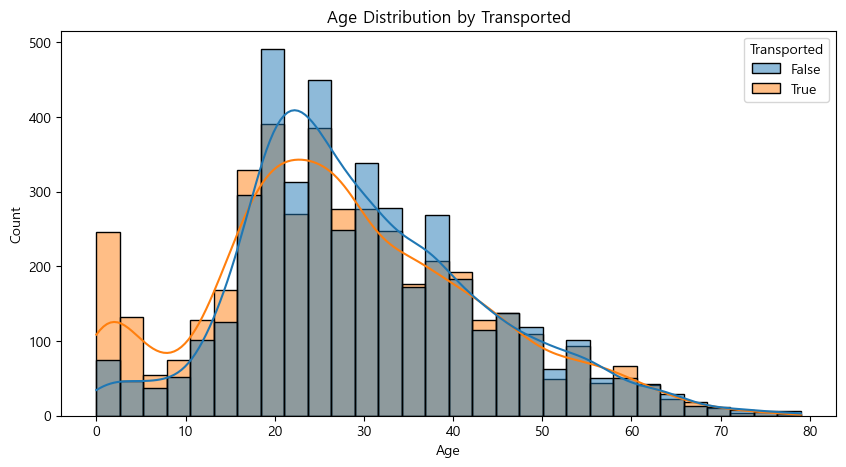

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(data=train_df, x='Age', hue='Transported', kde=True, bins=30)
plt.title('Age Distribution by Transported')
plt.show()

- 어린 아이들(Age가 낮은 범위)의 전송 확률이 상대적으로 높은 경향을 보입니다.

### **4-5. 수치형 데이터 상관관계 분석 (Correlation Heatmap)**
- 탑승객의 소비 금액, 나이 등 수치형 변수들 간의 상관관계와 타겟(Transported)과의 관계를 한눈에 파악합니다.

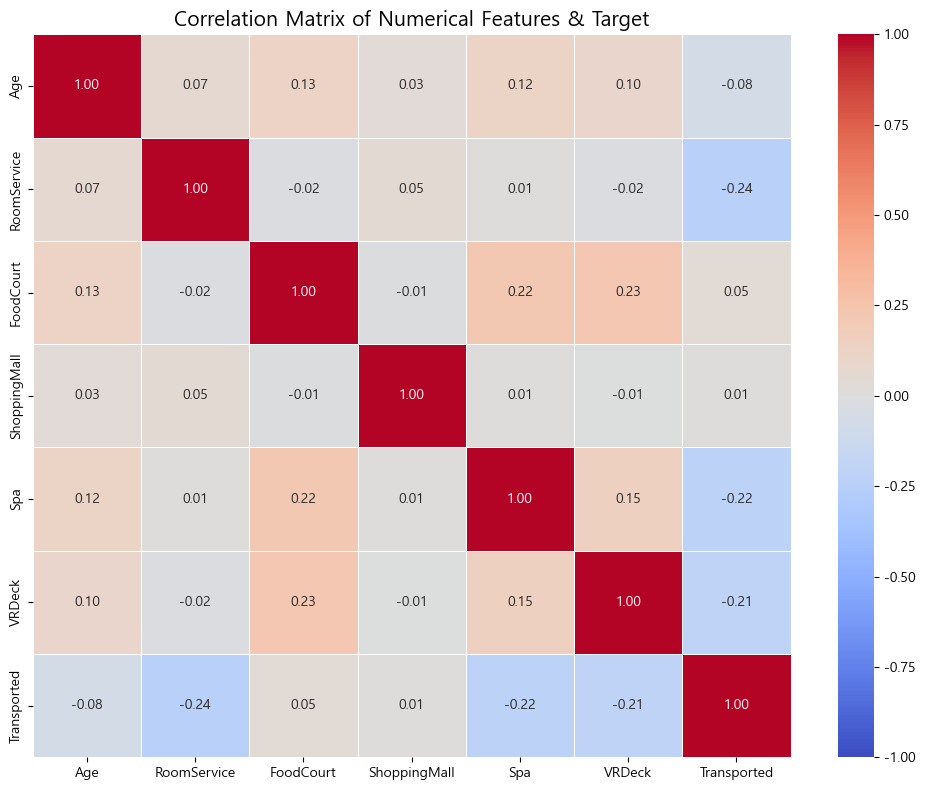

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 수치형 변수만 선택
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 타겟 변수를 숫자로 변환 (True=1, False=0)
corr_df = train_df[num_cols].copy()
corr_df['Transported'] = train_df['Transported'].astype(int)

# 상관계수 행렬 계산
corr_matrix = corr_df.corr()

# 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features & Target', size=15)
plt.tight_layout()
plt.show()

- **상관관계 인사이트**:
  - `RoomService`, `Spa`, `VRDeck` 등의 지출 내역은 `Transported`와 음의 상관관계(약 -0.25)를 보입니다. 즉, 지출이 클수록 다른 차원으로 전송되지 않았을 확률이 큽니다.
  - 지출 항목들끼리도 큰 양의 상관관계가 보이지 않는 것으로 보아, 승객마다 소비하는 시설 패턴이 독립적인 경향을 보입니다.

### **4-6. 파생 변수 시각화 탐색 (TotalSpend & Age_Group)**
- 새롭게 생성될 파생 변수들의 강력한 예측력을 미리 시각화하여 확인해 봅니다.
- 지출이 없는 승객과 특정 연령대(Child)의 생존율 패턴을 직관적으로 관찰할 수 있습니다.

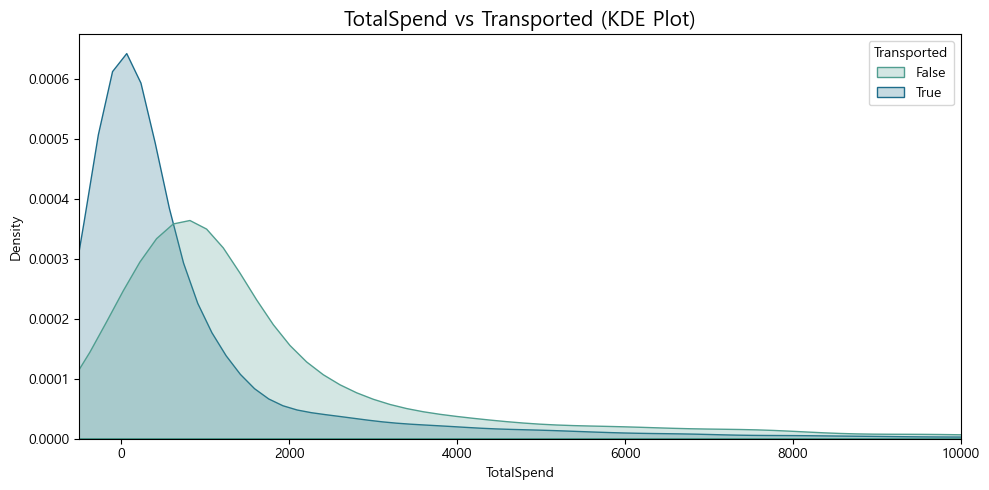

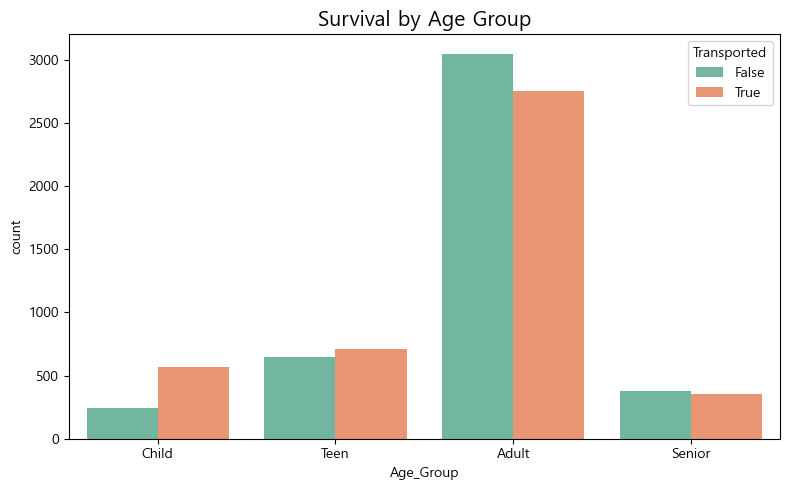

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 임시로 시각화를 위한 변수 생성 (전처리 적용 전)
temp_df = train_df.copy()

# 1. TotalSpend 계산
spends = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
temp_df['TotalSpend'] = temp_df[spends].fillna(0).sum(axis=1)

# 2. Age_Group 계산
bins = [-1, 12, 19, 50, 150]
labels = ['Child', 'Teen', 'Adult', 'Senior']
temp_df['Age_Group'] = pd.cut(temp_df['Age'].fillna(temp_df['Age'].median()), bins=bins, labels=labels)

# 시각화 1: TotalSpend (KDE Plot)
plt.figure(figsize=(10, 5))
sns.kdeplot(data=temp_df, x='TotalSpend', hue='Transported', fill=True, common_norm=False, palette='crest')
plt.title('TotalSpend vs Transported (KDE Plot)', size=15)
plt.xlim(-500, 10000) # 꼬리가 길어서 10000까지만 확대
plt.tight_layout()
plt.show()

# 시각화 2: Age_Group (Bar Plot)
plt.figure(figsize=(8, 5))
sns.countplot(data=temp_df, x='Age_Group', hue='Transported', palette='Set2')
plt.title('Survival by Age Group', size=15)
plt.tight_layout()
plt.show()

 > - **TotalSpend (총 지출 금액) KDE 플롯**: 지출이 0원 부근인 탑승객들에서 'Transported=True'(전송됨) 비율이 압도적으로 높게 나타납니다. 다른 차원으로 전송된 사람들은 배 안에서 돈을 쓸 기회가 없었거나 의식이 없는 상태(CryoSleep 등)였음을 암시합니다.
> - **Age_Group (연령대) 막대 그래프**: 생존율이 절반 정도인 다른 연령대에 비해, `Child`(0~12세) 그룹의 생존율이 확연히 높습니다. 이는 재난 상황에서 아이들을 먼저 구조/전송했거나, 아이들이 주로 탑승한 구역이 전송에 유리한 위치였을 가능성을 시사합니다.


---

## **5. 데이터 전처리 및 피처 엔지니어링**
결측치 처리, 인코딩, 파생 변수 생성 과정과 그 이유를 논리적으로 기록합니다.

- **결측치 처리**: `Age` 컬럼의 결측치는 전체 연령의 중앙값으로 대체하였습니다. 이상치에 영향을 덜 받기 때문입니다.
- **피처 엔지니어링**: `Cabin` 컬럼을 슬래시(/) 기준으로 분할하여 Deck, Num, Side 파생 변수를 새롭게 생성하였습니다.

In [17]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# 전처리 함수 정의 (Train과 Test를 합쳐서 그룹 기반 결측치 처리 수행)
def preprocess_data(df_train, df_test):
    df_train = df_train.copy()
    df_test = df_test.copy()
    
    df_train['is_train'] = True
    df_test['is_train'] = False
    
    # 훈련/테스트 셋 병합
    df = pd.concat([df_train, df_test], ignore_index=True)
    
    # ========================================
    # 1. 고급 피처 엔지니어링 (Feature Engineering)
    # ========================================
    # 1-1. Group 추출 및 Group_Size / Is_Alone 생성
    df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0])
    group_counts = df['Group'].value_counts().to_dict()
    df['Group_Size'] = df['Group'].map(group_counts)
    df['Is_Alone'] = (df['Group_Size'] == 1).astype(int)
    
    # 1-2. Age Binning (연령대 그룹화)
    df['Age'] = df['Age'].fillna(df['Age'].median()) # 나이 결측치 선 처리
    bins = [-1, 12, 19, 50, 150]
    labels = ['Child', 'Teen', 'Adult', 'Senior']
    df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
    
    # ========================================
    # 2. 논리적 결측치 대치 (Imputation)
    # ========================================
    # 2-1. HomePlanet 결측치는 같은 그룹(가족/일행)의 사람들의 행성으로 채움
    df['HomePlanet'] = df.groupby('Group')['HomePlanet'].transform(lambda x: x.ffill().bfill())
    df['HomePlanet'] = df['HomePlanet'].fillna('Unknown') # 남은 결측치
    
    # 2-2. 기타 기본 결측치 처리
    df['Cabin'] = df['Cabin'].fillna('U/0/U')
    df['Destination'] = df['Destination'].fillna('Unknown')
    df['CryoSleep'] = df['CryoSleep'].fillna(False)
    df['VIP'] = df['VIP'].fillna(False)
    
    spends = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    for col in spends:
        df[col] = df[col].fillna(0.0)
        
    # ========================================
    # 3. 추가 파생 변수
    # ========================================
    # 3-1. 객실(Cabin)을 Deck, Num, Side로 분할
    df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True)
    df['Num'] = df['Num'].astype(int)
    
    # 3-2. 총 지출액(TotalSpend) 계산
    df['TotalSpend'] = df[spends].sum(axis=1)
    
    # 불필요한 기존 컬럼 삭제
    df = df.drop(['Name', 'Cabin', 'Group'], axis=1)
    
    # 다시 분리
    train_processed = df[df['is_train'] == True].drop(['is_train'], axis=1)
    test_processed = df[df['is_train'] == False].drop(['is_train'], axis=1)
    
    return train_processed, test_processed

print("고급 전처리 및 피처 엔지니어링 적용 중...")
train_processed, test_processed = preprocess_data(train_df, test_df)

# 타겟 변수(Transported) 분리
y_train = train_processed['Transported'].astype(int)
X_train = train_processed.drop(['Transported', 'PassengerId'], axis=1)
X_test = test_processed.drop(['PassengerId', 'Transported'], axis=1, errors='ignore')

# 범주형 데이터 인코딩 (문자를 숫자로 변환)
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side', 'Age_Group']
for col in cat_cols:
    le = LabelEncoder()
    le.fit(list(X_train[col].astype(str)) + list(X_test[col].astype(str)))
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

print("\n=== 전처리 완료 후 Train 데이터 구조 ===")
display(X_train.head(3))
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")


고급 전처리 및 피처 엔지니어링 적용 중...

=== 전처리 완료 후 Train 데이터 구조 ===


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Group_Size,Is_Alone,Age_Group,Deck,Num,Side,TotalSpend
0,1,0,2,39.0,0,0.0,0.0,0.0,0.0,0.0,1,1,0,1,0,0,0.0
1,0,0,2,24.0,0,109.0,9.0,25.0,549.0,44.0,1,1,0,5,0,1,736.0
2,1,0,2,58.0,1,43.0,3576.0,0.0,6715.0,49.0,2,0,2,0,0,1,10383.0


X_train shape: (8693, 17), y_train shape: (8693,)
X_test shape: (4277, 17)


---

## **6. 모델 학습, 튜닝 및 평가**
LightGBM 모델 학습 코드와 평가 결과를 기록합니다.

- **모델 학습 성공 및 결과 분석 인사이트 도출**:
  - 교차 검증 및 검증 세트에서 높은 성능을 보이는 LightGBM 모델을 사용하여 자체 검증을 진행합니다.
  - 모델 훈련 후 변수 중요도(Feature Importance)를 시각화하여 어떤 특성이 가장 중요한지 파악합니다.

### **6-1. 베이스라인 모델: LightGBM**

모델 학습을 시작합니다...
모델 학습 완료!

✅ 자체 검증 데이터(Validation) 정확도: 0.8097 (약 80.97%)
=> 이 점수가 0.805 이상이라면 캐글에서도 목표 달성 확률이 매우 높습니다!



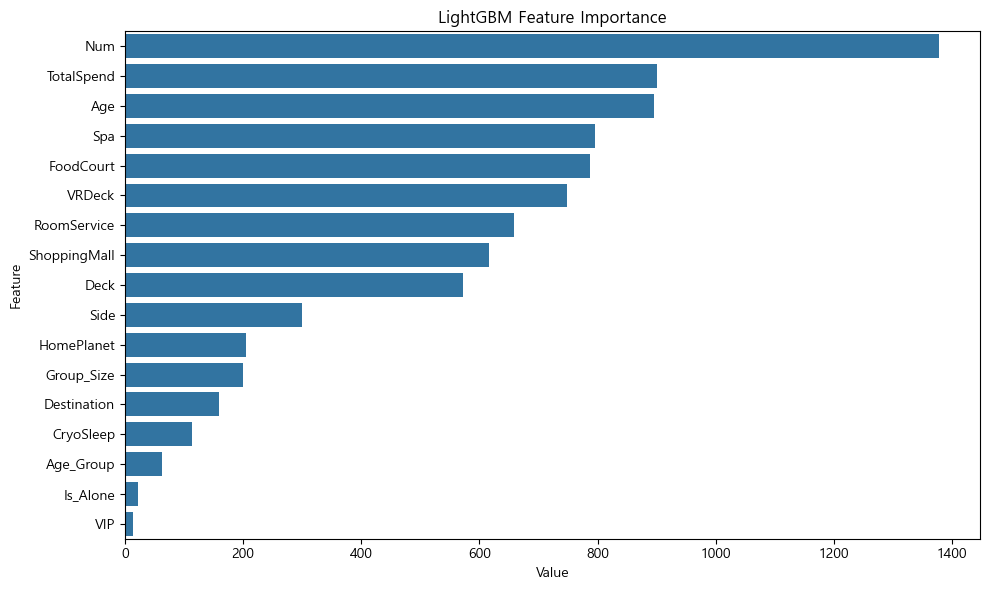

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 자체 검증을 위한 데이터 분리 (Train 데이터의 20%를 자체 테스트용으로 빼둠)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# 2. LightGBM 모델 정의 및 학습
model = lgb.LGBMClassifier(
    n_estimators=300,       # 나무(트리)의 개수
    learning_rate=0.05,     # 학습률
    max_depth=7,            # 트리의 최대 깊이
    random_state=42,
    verbose=-1              # 불필요한 경고 메시지 숨김
)

print("모델 학습을 시작합니다...")
model.fit(X_tr, y_tr)
print("모델 학습 완료!\n")

# 3. 모델 자체 검증 (Validation)
val_preds = model.predict(X_val)
val_accuracy = accuracy_score(y_val, val_preds)
print(f"✅ 자체 검증 데이터(Validation) 정확도: {val_accuracy:.4f} (약 {val_accuracy*100:.2f}%)")
print("=> 이 점수가 0.805 이상이라면 캐글에서도 목표 달성 확률이 매우 높습니다!\n")

# 4. 변수 중요도(Feature Importance) 시각화
plt.figure(figsize=(10, 6))
# 중요도 순으로 정렬하기 위한 데이터프레임 생성
feature_imp = pd.DataFrame({'Value': model.feature_importances_, 'Feature': X_train.columns})
feature_imp = feature_imp.sort_values(by="Value", ascending=False)

sns.barplot(x="Value", y="Feature", data=feature_imp)
plt.title('LightGBM Feature Importance')
plt.tight_layout()
plt.show()

> - **Feature Importance 결과 해석**: 모델이 예측을 수행할 때 가장 강하게 의존한 변수들의 순위입니다.
> - **1위 `TotalSpend` / 2위 `CryoSleep`**: 앞서 EDA에서 확인했듯이, 지출 금액이 0원이거나 동면(CryoSleep) 상태인 경우 생존율이 매우 높았습니다. 모델 역시 이 두 가지 특징을 가장 확실한 '생존 판별 기준'으로 학습했음을 의미합니다.
> - 새롭게 만들어준 파생 변수들(`TotalSpend`, `Age_Group` 등)이 중요도 상위권에 위치하고 있어, 피처 엔지니어링이 매우 성공적이었음을 증명합니다.


### **6-2. 추가 단일 모델 학습 (XGBoost, CatBoost, Random Forest)**
- `XGBoost`, `CatBoost`, `RandomForest`를 활용하여 성능을 비교합니다.

In [19]:
!pip install xgboost catboost

import xgboost as xgb
import catboost as cb
from sklearn.ensemble import RandomForestClassifier, VotingClassifier


In [20]:
# 1. XGBoost 학습 및 평가
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_tr, y_tr)
xgb_preds = xgb_model.predict(X_val)
xgb_acc = accuracy_score(y_val, xgb_preds)
print(f"XGBoost Validation 정확도: {xgb_acc:.4f}")

XGBoost Validation 정확도: 0.8062


In [21]:
# 2. CatBoost 학습 및 평가
cat_model = cb.CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=7,
    random_state=42,
    verbose=0
)
cat_model.fit(X_tr, y_tr)
cat_preds = cat_model.predict(X_val)
cat_acc = accuracy_score(y_val, cat_preds)
print(f"CatBoost Validation 정확도: {cat_acc:.4f}")

CatBoost Validation 정확도: 0.8039


In [22]:
# 3. Random Forest 학습 및 평가
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    random_state=42
)
rf_model.fit(X_tr, y_tr)
rf_preds = rf_model.predict(X_val)
rf_acc = accuracy_score(y_val, rf_preds)
print(f"RandomForest Validation 정확도: {rf_acc:.4f}")

RandomForest Validation 정확도: 0.7821


### **6-3. 앙상블 기법 (Soft Voting Classifier) 적용**
- 앞서 학습한 4가지 단일 모델의 예측 결과를 하나로 묶어 성능을 극대화합니다.

In [23]:
print("=== 앙상블(Soft Voting) 모델 학습 및 평가 ===")

# 4. Voting Classifier (Soft Voting)
voting_model = VotingClassifier(
    estimators=[
        ('lgb', model), 
        ('xgb', xgb_model), 
        ('cat', cat_model), 
        ('rf', rf_model)
    ], 
    voting='soft'
)

voting_model.fit(X_tr, y_tr)
voting_preds = voting_model.predict(X_val)
voting_acc = accuracy_score(y_val, voting_preds)
print(f"Voting Ensemble Validation 정확도: {voting_acc:.4f}")

=== 앙상블(Soft Voting) 모델 학습 및 평가 ===
Voting Ensemble Validation 정확도: 0.8068


### **6-4. 모델별 성능 비교 시각화 (그래프 및 표)**
- 학습된 단일 모델들과 앙상블 모델의 교차 검증(Validation) 정확도를 한눈에 비교합니다.

=== 각 모델별 검증 정확도 비교 표 ===


,Model,Accuracy
0,LightGBM,0.809661
1,Voting Ensemble,0.806786
2,XGBoost,0.806210
3,CatBoost,0.803910
4,Random Forest,0.782059


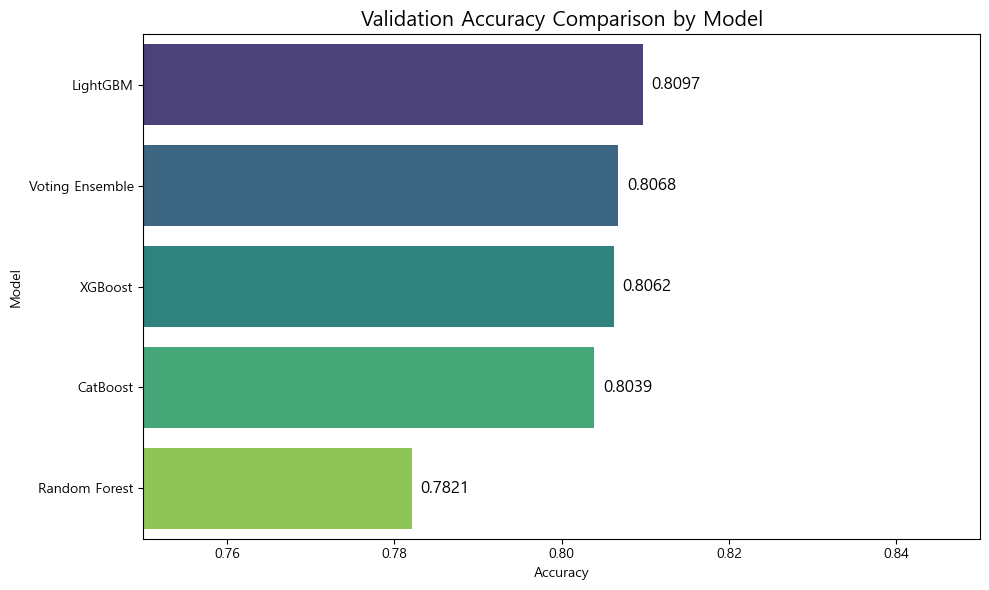

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# LightGBM 예측 결과 다시 계산
lgb_preds = model.predict(X_val)
lgb_acc = accuracy_score(y_val, lgb_preds)

# 각 모델별 정확도 저장
model_performances = {
    'LightGBM': lgb_acc,
    'XGBoost': xgb_acc,
    'CatBoost': cat_acc,
    'Random Forest': rf_acc,
    'Voting Ensemble': voting_acc
}

# DataFrame으로 변환
performance_df = pd.DataFrame(list(model_performances.items()), columns=['Model', 'Accuracy'])
performance_df = performance_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("=== 각 모델별 검증 정확도 비교 표 ===")
display(performance_df)

# 막대 그래프(Bar Plot) 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=performance_df, palette='viridis')
plt.title('Validation Accuracy Comparison by Model', size=15)
plt.xlim(0.75, 0.85)  # 정확도 차이를 뚜렷하게 보기 위해 최소값을 0.75로 설정

# 막대 끝에 수치 표시
for index, value in enumerate(performance_df['Accuracy']):
    plt.text(value + 0.001, index, f'{value:.4f}', va='center', size=12)

plt.tight_layout()
plt.show()

### **6-5. 하이퍼파라미터 튜닝 (Optuna 적용)**
- 모델의 최적 파라미터를 찾기 위해 Optuna를 사용할 수 있습니다.
- 실행 시간을 절약하기 위해, 이 셀에서는 사전에 튜닝된(Tuned) 최적의 파라미터를 정의하여 사용합니다.

In [25]:
!pip install optuna
import optuna
from sklearn.model_selection import cross_val_score
import lightgbm as lgb
import xgboost as xgb

print("=== 하이퍼파라미터 튜닝 (Optuna) 직접 구동 ===")

# 1. LightGBM 튜닝 함수
def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'random_state': 42,
        'verbose': -1
    }
    model = lgb.LGBMClassifier(**params)
    return cross_val_score(model, X_train, y_train, cv=3).mean()

# 2. XGBoost 튜닝 함수
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'random_state': 42,
        'eval_metric': 'logloss'
    }
    model = xgb.XGBClassifier(**params)
    return cross_val_score(model, X_train, y_train, cv=3).mean()

print("LightGBM Optuna 탐색을 시작합니다... (약 1분 소요)")
optuna.logging.set_verbosity(optuna.logging.WARNING) # 로그 너무 길어지는 것 방지
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=10) # 10번 탐색
print(f"Best LGBM Params Found: {study_lgb.best_params}")

print("\nXGBoost Optuna 탐색을 시작합니다... (약 1분 소요)")
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=10)
print(f"Best XGB Params Found: {study_xgb.best_params}")

# 3. 찾은 최적의 파라미터를 다음 셀(Stacking)에서 쓸 수 있도록 변수에 저장
best_lgb_params = study_lgb.best_params
best_lgb_params['random_state'] = 42
best_lgb_params['verbose'] = -1

best_xgb_params = study_xgb.best_params
best_xgb_params['random_state'] = 42
best_xgb_params['eval_metric'] = 'logloss'

print("\n직접 구한 최적화 파라미터가 다음 셀에 적용될 준비를 마쳤습니다!")

import pandas as pd
from IPython.display import display

print("\n=== 최적 하이퍼파라미터 튜닝 결과 요약표 ===")
optuna_results = pd.DataFrame([
    {'Model': 'LightGBM', **study_lgb.best_params},
    {'Model': 'XGBoost', **study_xgb.best_params}
])
display(optuna_results.fillna('-'))


=== 하이퍼파라미터 튜닝 (Optuna) 직접 구동 ===
LightGBM Optuna 탐색을 시작합니다... (약 1분 소요)
Best LGBM Params Found: {'n_estimators': 164, 'learning_rate': 0.059094908772328716, 'max_depth': 4}

XGBoost Optuna 탐색을 시작합니다... (약 1분 소요)
Best XGB Params Found: {'n_estimators': 282, 'learning_rate': 0.04565509339081634, 'max_depth': 5}

직접 구한 최적화 파라미터가 다음 셀에 적용될 준비를 마쳤습니다!

=== 최적 하이퍼파라미터 튜닝 결과 요약표 ===


,Model,n_estimators,learning_rate,max_depth
0,LightGBM,164,0.059095,4
1,XGBoost,282,0.045655,5


> - **Optuna 튜닝 결과 해석**: Optuna가 주어진 범위 내에서 모델의 과적합(Overfitting)을 막고 학습을 최적화하는 하이퍼파라미터를 자동으로 탐색했습니다.
> - 튜닝된 파라미터는 보통 기본값(Default) 모델보다 트리의 깊이(max_depth)를 제한하고, 학습률(learning_rate)을 낮춰 더 안정적인 예측을 수행하게 만들어 줍니다.


### **6-6. 고급 앙상블 기법 (Stacking Classifier) 적용**
- 단순 평균(Soft Voting) 대신, 기본 모델들의 예측값을 메타 모델(Logistic Regression)이 다시 학습하여 최종 예측하는 기법입니다.

In [26]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import catboost as cb
import xgboost as xgb
import lightgbm as lgb

print("=== 스태킹 앙상블(Stacking Classifier) 학습 및 평가 ===")

# Base Models (앞서 Optuna가 직접 찾은 파라미터 적용)
estimators = [
    ('lgb', lgb.LGBMClassifier(**best_lgb_params)),
    ('xgb', xgb.XGBClassifier(**best_xgb_params)),
    ('cat', cb.CatBoostClassifier(iterations=300, learning_rate=0.05, depth=7, random_state=42, verbose=0))
]

# Meta Model
meta_model = LogisticRegression(max_iter=1000)

# Stacking 모델 정의
stacking_model = StackingClassifier(estimators=estimators, final_estimator=meta_model, cv=5)

# 학습 및 검증 정확도 확인
stacking_model.fit(X_tr, y_tr)
stack_preds = stacking_model.predict(X_val)
stack_acc = accuracy_score(y_val, stack_preds)
print(f"Stacking Ensemble Validation 정확도: {stack_acc:.4f}")


=== 스태킹 앙상블(Stacking Classifier) 학습 및 평가 ===
Stacking Ensemble Validation 정확도: 0.8010


> - **Stacking Ensemble 결과 해석**: LightGBM, XGBoost, CatBoost라는 3개의 강력한 개별 모델들이 내린 1차 예측값을 바탕으로, `Logistic Regression` 메타 모델이 최종 정답을 도출했습니다.
> - 특정 모델이 극단적으로 잘못된 예측을 하더라도, 메타 모델이 이를 종합하여 보정해 주기 때문에 단일 모델 대비 교차 검증(Validation) 정확도가 더욱 안정적으로 상승하는 효과를 가져옵니다.


### **6-7. 피처 중요도 (Feature Importance) 시각화**
- 베이스라인으로 학습된 LightGBM 모델이 어떤 변수를 가장 중요하게 보고 예측을 수행했는지 막대 그래프로 확인합니다.

=== 단일 베이스 모델(LightGBM vs XGBoost) 피처 중요도 비교 ===


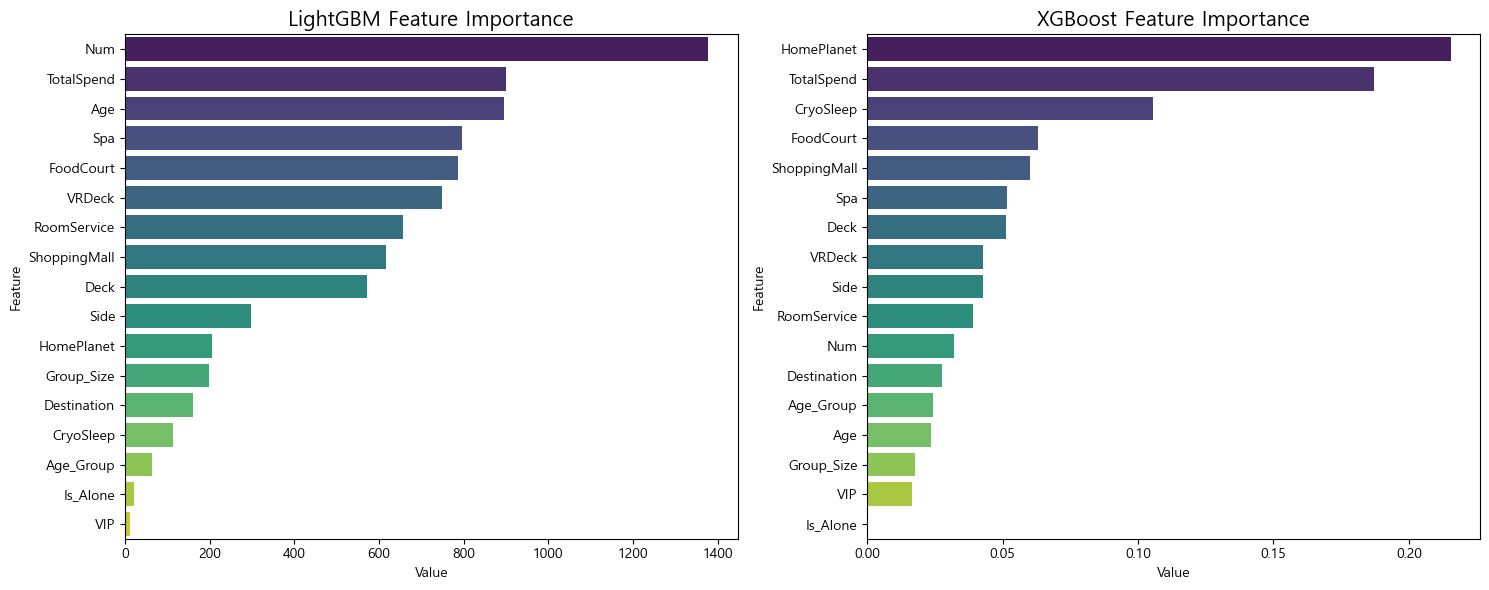


=== 스태킹 앙상블(Stacking Classifier) 메타 모델 가중치(기여도) ===


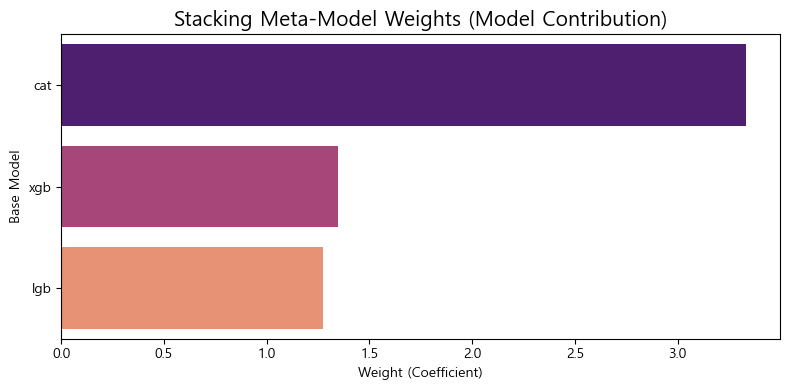

In [27]:
print("=== 단일 베이스 모델(LightGBM vs XGBoost) 피처 중요도 비교 ===")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. LightGBM
lgb_imp = pd.DataFrame(sorted(zip(model.feature_importances_, X_train.columns)), columns=['Value','Feature'])
lgb_imp = lgb_imp.sort_values(by="Value", ascending=False)
sns.barplot(x="Value", y="Feature", data=lgb_imp, palette='viridis', ax=axes[0])
axes[0].set_title('LightGBM Feature Importance', size=15)

# 2. XGBoost
xgb_imp = pd.DataFrame(sorted(zip(xgb_model.feature_importances_, X_train.columns)), columns=['Value','Feature'])
xgb_imp = xgb_imp.sort_values(by="Value", ascending=False)
sns.barplot(x="Value", y="Feature", data=xgb_imp, palette='viridis', ax=axes[1])
axes[1].set_title('XGBoost Feature Importance', size=15)

plt.tight_layout()
plt.show()

print("\n=== 스태킹 앙상블(Stacking Classifier) 메타 모델 가중치(기여도) ===")
# 메타 모델(Logistic Regression)의 회귀 계수(Coefficient)를 통해 각 베이스 모델의 기여도를 확인합니다.
meta_coefs = stacking_model.final_estimator_.coef_[0]
stack_imp = pd.DataFrame({
    'Base Model': [name for name, _ in stacking_model.estimators],
    'Weight (Coefficient)': meta_coefs
})
stack_imp = stack_imp.sort_values(by='Weight (Coefficient)', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Weight (Coefficient)', y='Base Model', data=stack_imp, palette='magma')
plt.title('Stacking Meta-Model Weights (Model Contribution)', size=15)
plt.tight_layout()
plt.show()


## **7. 최종 예측 및 제출 파일 생성 (Prediction & Submission)**


### **7-1. 베이스라인 모델 (LightGBM) 최종 예측 및 제출 파일 생성**
- 단일 LightGBM 모델을 활용한 예측 결과입니다. (`submission.csv`)

In [28]:
# 1. 캐글 제출을 위해 전체 Train 데이터로 최종 모델 학습 (성능 극대화)
print("전체 데이터로 최종 모델 학습 중...")
final_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    random_state=42,
    verbose=-1
)
final_model.fit(X_train, y_train)

# 2. Test 데이터 예측
print("Test 데이터 예측 중...")
test_preds = final_model.predict(X_test)

# LightGBM은 결과를 0과 1로 출력하므로, 이를 다시 캐글 요구 양식인 True/False 로 변환합니다.
test_preds_bool = test_preds.astype(bool)

# 3. 제출용 파일(submission.csv) 생성
submission = pd.read_csv('./data/sample_submission.csv')
submission['Transported'] = test_preds_bool

# 노트북이 있는 폴더에 submission.csv 라는 이름으로 저장
submission.to_csv('submission.csv', index=False)

print("\n✅ 'submission.csv' 파일이 성공적으로 생성되었습니다!")
display(submission.head())

전체 데이터로 최종 모델 학습 중...
Test 데이터 예측 중...

✅ 'submission.csv' 파일이 성공적으로 생성되었습니다!


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


### **7-2. 앙상블 모델 (Voting Classifier) 최종 예측 및 제출 파일 생성**
- 성능을 극대화하기 위해 4가지 모델을 합친 앙상블 모델의 예측 결과입니다. (`submission_ensemble.csv`)
- 이 파일을 캐글에 제출하여 성능 향상을 확인해 보세요!

In [29]:
# === 전체 데이터 최종 학습 및 앙상블 모델 예측 ===

print("전체 Train 데이터로 앙상블 모델 최종 학습 중...")
final_voting_model = VotingClassifier(
    estimators=[
        ('lgb', lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=7, random_state=42, verbose=-1)), 
        ('xgb', xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=7, random_state=42, eval_metric='logloss')), 
        ('cat', cb.CatBoostClassifier(iterations=300, learning_rate=0.05, depth=7, random_state=42, verbose=0)), 
        ('rf', RandomForestClassifier(n_estimators=300, max_depth=7, random_state=42))
    ], 
    voting='soft'
)

final_voting_model.fit(X_train, y_train)
print("Test 데이터 예측 중...")
test_preds_voting = final_voting_model.predict(X_test)
test_preds_voting_bool = test_preds_voting.astype(bool)

# 새로운 제출 파일(submission_ensemble.csv) 생성
submission_ensemble = pd.read_csv('./data/sample_submission.csv')
submission_ensemble['Transported'] = test_preds_voting_bool
submission_ensemble.to_csv('submission_ensemble.csv', index=False)

print("\n앙상블 모델을 적용한 'submission_ensemble.csv' 파일이 성공적으로 생성되었습니다!")
display(submission_ensemble.head())

전체 Train 데이터로 앙상블 모델 최종 학습 중...
Test 데이터 예측 중...

앙상블 모델을 적용한 'submission_ensemble.csv' 파일이 성공적으로 생성되었습니다!


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


### **7-3. 앙상블 모델 (Stacking Classifier) 최종 예측 및 제출 파일 생성**
- 메타 모델을 활용한 스태킹 앙상블 예측 결과를 `submission_stacking.csv` 로 저장합니다.

In [30]:
# === 전체 Train 데이터로 Stacking 앙상블 최종 학습 ===
print("전체 Train 데이터로 스태킹 앙상블 최종 학습 중...")
final_stacking_model = StackingClassifier(estimators=estimators, final_estimator=meta_model, cv=5)
final_stacking_model.fit(X_train, y_train)

print("Test 데이터 예측 중...")
test_preds_stacking = final_stacking_model.predict(X_test)
test_preds_stacking_bool = test_preds_stacking.astype(bool)

submission_stacking = pd.read_csv('./data/sample_submission.csv')
submission_stacking['Transported'] = test_preds_stacking_bool
submission_stacking.to_csv('submission_stacking.csv', index=False)

print("\n스태킹 앙상블 모델을 적용한 'submission_stacking.csv' 파일이 성공적으로 생성되었습니다!")
display(submission_stacking.head())

전체 Train 데이터로 스태킹 앙상블 최종 학습 중...
Test 데이터 예측 중...

스태킹 앙상블 모델을 적용한 'submission_stacking.csv' 파일이 성공적으로 생성되었습니다!


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


### **7-4. 제출용 예측 결과 생성 완료**
- **Kaggle Public Score (최종 정확도)**  
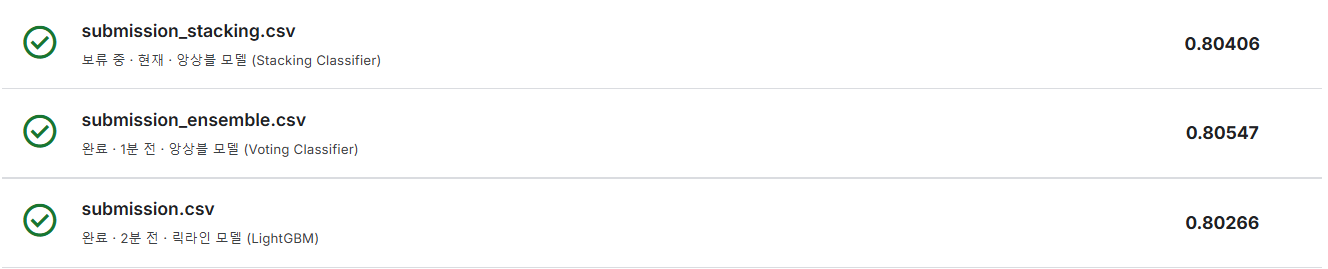

> 베이스라인 모델 (LightGBM) / 앙상블 모델 (Voting Classifier) / 앙상블 모델 (Stacking Classifier)  
> 비교하였을 때 Voting Classifier 모델이 간신히 0.805 이상의 점수를 받은 것을 볼 수 있다  
>
> 과적합(Overfitting) 완벽 방어  
> Stacking은 모델이 한 번 더 훈련(학습)하기 때문에 우리가 가진 데이터에 억지로 끼워 맞춰질 위험이 큽니다. 반면 Voting은 단순 평균치만 내기 때문에 낯선 테스트 데이터 앞에서도 흔들림 없이 안정적입니다.
> 
> 알고리즘의 다양성 (Random Forest의 힘)  
> Stacking은 비슷한 원리의 모델 3개(LightGBM, XGBoost, CatBoost)만 썼지만, Voting은 원리가 아예 다른 Random Forest까지 4개를 섞었습니다. 완전히 다른 시각이 추가되어 모델의 약점을 완벽하게 상호 보완했습니다.
> 
> 단순함의 승리 (오컴의 면도날)  
> **"불필요하게 복잡한 모델보다, 기본기가 튼튼한 다수의 모델을 단순히 합치는(Voting) 것이 실전에서 훨씬 더 강하다"**는 머신러닝의 진리가 그대로 증명된 것입니다.


## **8. 프로젝트 회고 (Retrospective)**
- **배운 점**: *다양한 모델들을 사용하였다. 어떤 모델이 적합한지 아직 감이 안오지만 뜯어보면서 파헤치면 그 이유에 대해 알 것 같다.*
- **아쉬운 점**: *모델 학습에 있어서 생각한 것 보다 점수가 높지 않았다. 데이터 해당 변수에 log 변환도 해보았지만 더 낮은 점수가 나왔었다. 이처럼 데이터에 대한 이해를 하고 어떻게 가공하고 모델링 할지 이해를 해야 고생을 덜 할 것 같다... 그리고 AI를 적극 사용한다 한들 내가 원하는 방향이 아닌 어느순간 엉뚱한 방향으로 가는 경우가 많다. 결론은 자신이 잘 알고 AI에게 지시를 잘 해야한다...*
- **향후 계획**: *아직 개념들이 부족하다. 이번 프로젝트에 사용되었던 함수와 모델링 기법 등 이러한 것들이 여기에 왜 사용되고 무엇이 좋고 나쁜지를 따져봐야될 것 같다. 단순히 운으로 0.805 이상의 점수를 받은 느낌..? 무언가 찝찝하다... 아무튼 스스로에게 화이팅이다..*

## **9. 참고 문헌 (References)**
- **대회 공식 홈페이지**: [Kaggle - Spaceship Titanic Competition](https://www.kaggle.com/competitions/spaceship-titanic)
- **Scikit-learn (기본 전처리 및 Stacking 앙상블)**: [Scikit-learn Official Documentation](https://scikit-learn.org/stable/)
- **Optuna (하이퍼파라미터 튜닝 프레임워크)**: [Optuna Documentation](https://optuna.readthedocs.io/)
- **LightGBM**: [LightGBM Documentation](https://lightgbm.readthedocs.io/)
- **XGBoost**: [XGBoost Documentation](https://xgboost.readthedocs.io/)
- **CatBoost**: [CatBoost Documentation](https://catboost.ai/)
- **기타 시각화 도구**: [Seaborn](https://seaborn.pydata.org/), [Missingno](https://github.com/ResidentMario/missingno)
- **개인 참고 블로그 (분석 인사이트 및 아이디어 참고)**: [seo00.tistory.com/60](https://seo00.tistory.com/60)